# Chromatin Loops Connection with Age - Non-Neurons

This notebook analyzes the relationship between chromatin loop changes in schizophrenia and age-related changes in healthy controls across different loop size groups.

In [ ]:
import pandas as pd
import numpy as np
from itertools import chain
from tqdm import tqdm
import os
from os import listdir
import glob
import json
import seaborn as sns
import cooler
import bioframe
import cooltools
from matplotlib_venn import venn2
from cooltools.lib.numutils import fill_diag
from statsmodels.stats.multitest import multipletests
from os.path import isfile, join
import warnings
import logging
import math
import matplotlib.pyplot as plt
import scipy
import bioframe as bf
import scipy.stats as stats
from statannot import add_stat_annotation
from scipy.stats import ttest_ind, mannwhitneyu, fisher_exact
import pyranges as pr
from pybedtools import BedTool as pbt
import upsetplot
import gseapy as gp
from gseapy import barplot, dotplot
import rpy2
from statsmodels.stats.multitest import fdrcorrection
from collections import defaultdict
import concurrent.futures
from matplotlib.colors import PowerNorm
from dotenv import load_dotenv

warnings.simplefilter(action='ignore', category=FutureWarning)
%load_ext rpy2.ipython
assert os.environ['CONDA_DEFAULT_ENV'] == "hic"

In [4]:
save_name = "loops_SZ_vs_Healthy"
path_to_loops_clusters_data = "./loops_cooltools_data_noSexChromosomes/loops_clusters_data_15kb"
name_appender="_reducedFiltering"
merged_all_clusters =pd.read_pickle(f"{path_to_loops_clusters_data}/{save_name}_calculated_clusters_all{name_appender}.pickle")
merged_all_clusters['num'] = [i for i in range(merged_all_clusters.shape[0])]

merged_all_clusters['group'] = merged_all_clusters.source.apply(lambda x: "SZ" if "SZ" in x else "Healthy")

In [5]:
merged_all_clusters.cluster.nunique()

8151

In [6]:
samples_with_age = {
'HC-2Mplus': 62,
'HC-3Mplus': 36,
'HC-91plus': 59,
'HC24plus': 54,
'HC-318plus': 58,
'HCM12plus': 35,
'SZ-01plus': 36,
'SZ-03plus': 57,
'SZ08plus': 56,
'SZ10plus': 50,
'SZ20plus': 37,
'SZ6plus': 62
}
samples_with_age = {k.replace('plus', 'minus'): v for k, v in samples_with_age.items()}

age_group = {}
for label, age in samples_with_age.items():
    if age <= 40:
        age_group[label] = "Young"
    elif 40 < age <= 57:
        age_group[label] = "Adult"
    else:
        age_group[label] = "Adult"

merged_all_clusters['sample_name'] = merged_all_clusters.source.apply(lambda x: x.split("_")[0])
merged_all_clusters['age_group'] = merged_all_clusters['sample_name'].map(age_group)

In [7]:
df = merged_all_clusters[[ 'num','cluster', 'intensity_mean', 'intensity_median', 'group', 'age_group']]

In [8]:
sizes = merged_all_clusters[['chrom1', 'start1', 'start2', 'cluster']].groupby('cluster').mean().reset_index().round(0)
sizes = sizes.merge(merged_all_clusters[['cluster', 'chrom1']].drop_duplicates().reset_index(drop=True), on ='cluster', how='left')
sizes = sizes[['chrom1','start1', 'start2', 'cluster']].reset_index(drop=True)
sizes = sizes.sort_values(['chrom1', 'start2']).reset_index(drop=True)
sizes_loops =sizes.copy()
sizes_loops['size'] = sizes_loops['start2'] - sizes_loops['start1']

quantiles = np.quantile(sizes_loops['size'], [0, 0.33, 0.67, 1.0])
print(quantiles)

[ 122500.  252500.  387500. 2966250.]


In [ ]:
quantiles = np.quantile(sizes_loops['size'], [0, 0.33, 0.67, 1.0])
print(quantiles) 
size_labels = ['small', 'medium', 'large']

sizes_loops['size_group'] = pd.cut(
    sizes_loops['size'],
    bins=quantiles,
    labels=size_labels,
    include_lowest=True,
    duplicates='drop'  
)

In [10]:
sizes_loops.groupby('size_group').mean()

,start1,start2,size
size_group,,,
small,8.215788e+07,8.235145e+07,193573.469764
medium,8.250422e+07,8.281897e+07,314742.128122
large,8.284110e+07,8.344931e+07,608213.284753


In [11]:
def get_cluster_group_stats(df, group_col, stat_col, group1, group2):
    out = (
        df[df[group_col].isin([group1, group2])]
        .groupby(['cluster', group_col])[stat_col]
        .median()
        .unstack()
        .rename(columns={group1: f"{group_col}_{group1}", group2: f"{group_col}_{group2}"})
    )
    return out

def loops_size_group_analysis(
    df, 
    sizes_tads,
    border_size_group_value, 
    N_QUANTILES=10, 
    group_col='group',
    stat_col='intensity_median',
    cluster_col='cluster',
    border_group_col='size_group',
    age_group_col='age_group',
    plot_prefix='./loops_visualizations/glia_loops',
    apply_filter=True
):
    sel_cl = sizes_tads[sizes_tads[border_group_col] == border_size_group_value].cluster.tolist()
    if apply_filter:
    
        sub_df = df[df["cluster"].isin(sel_cl)]
    else:
        sub_df= df.copy()

    sz_hc = get_cluster_group_stats(sub_df, group_col, stat_col, 'SZ', 'Healthy')
    sz_hc['sz_hc_log2fc'] = np.log2(sz_hc['group_SZ'] / sz_hc['group_Healthy'])

    healthy = sub_df[sub_df[group_col] == 'Healthy']
    hc_age = (
        healthy.groupby([cluster_col, age_group_col])[stat_col]
        .median()
        .unstack()
        .rename(columns={'Young':'HC_Young', 'Adult':'HC_Adult'})
    )
    hc_age['hc_old_young_log2fc'] = np.log2(hc_age['HC_Adult'] / hc_age['HC_Young'])

    merged = pd.merge(sz_hc, hc_age, left_index=True, right_index=True, how='inner').dropna(
        subset=['sz_hc_log2fc','hc_old_young_log2fc'])
    merged['sz_hc_quantile'] = pd.qcut(
        merged['sz_hc_log2fc'], N_QUANTILES, labels=False, duplicates='drop')
    merged['hc_old_young_quantile'] = pd.qcut(
        merged['hc_old_young_log2fc'], N_QUANTILES, labels=False, duplicates='drop')

    top_sz_hc = merged[merged['sz_hc_quantile'] == merged['sz_hc_quantile'].max()].index
    top_hc_age = merged[merged['hc_old_young_quantile'] == merged['hc_old_young_quantile'].max()].index

    overlap_clusters = set(top_sz_hc) & set(top_hc_age)
    print(f'[border_size_group={border_size_group_value}] Number of top_sz_hc: {len(top_sz_hc)}')
    print(f'[border_size_group={border_size_group_value}] Number of top_hc_age: {len(top_hc_age)}')
    print(f'[border_size_group={border_size_group_value}] Number of overlapping clusters in top quantile: {len(overlap_clusters)}')

    # --- Fisher's exact test for enrichment ---
    # | in_top_SZ_and_top_HC | in_top_SZ_not_in_top_HC |
    # |----------------------|------------------------ |
    # | in_top_HC_not_top_SZ | in_neither             |
    table = [
        [len(set(top_sz_hc) & set(top_hc_age)), len(set(top_sz_hc) - set(top_hc_age))],
        [len(set(top_hc_age) - set(top_sz_hc)), len(merged) - len(set(top_sz_hc) | set(top_hc_age))]
    ]
    oddsratio, pval = fisher_exact(table, alternative='greater')
    print(f"[border_size_group={border_size_group_value}] Fisher's exact test p-value for enrichment: {pval:.3g}, odds ratio: {oddsratio:.3g}")

    # --- Quantile intersection matrices ---
    TOTAL_NUM = len(merged.index)
    similarity_matrix = np.zeros((N_QUANTILES, N_QUANTILES))
    intersection_percentage_matrix = np.zeros((N_QUANTILES, N_QUANTILES))

    for i in range(N_QUANTILES):
        sz_clusters = set(merged[merged['sz_hc_quantile'] == i].index)
        sz_size = len(sz_clusters)
        for j in range(N_QUANTILES):
            hc_clusters = set(merged[merged['hc_old_young_quantile'] == j].index)
            intersection = len(sz_clusters & hc_clusters)
            union = len(sz_clusters | hc_clusters)
            similarity = (intersection / union) if union > 0 else 0
            similarity_matrix[i, j] = similarity
            if sz_size > 0:
                intersection_percentage_matrix[i, j] = intersection / TOTAL_NUM
            else:
                intersection_percentage_matrix[i, j] = 0

    # --- Heatmap Plots ---
    plt.rcParams["svg.fonttype"] = "none"
    # Jaccard similarity
    plt.figure(figsize=(8,7))
    ax = sns.heatmap(
        similarity_matrix,
        annot=True,
        fmt=".2f",
        cmap='Blues',
        norm=PowerNorm(gamma=0.5),
        xticklabels=[f'Q{i+1}' for i in range(N_QUANTILES)],
        yticklabels=[f'Q{i+1}' for i in range(N_QUANTILES)]
    )
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.xticks(rotation=45, ha='left')
    plt.title(f'Jaccard similarity (cluster={border_size_group_value})', pad=20)
    plt.xlabel('HC Adult/Young quantiles')
    plt.ylabel('SZ/HC quantiles')
    plt.tight_layout()
    plt.savefig(f'{plot_prefix}_q{N_QUANTILES}_jaccard_cluster_{border_size_group_value}.pdf', bbox_inches='tight')
    plt.savefig(f'{plot_prefix}_q{N_QUANTILES}_jaccard_cluster_{border_size_group_value}.svg', bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8,7))
    ax = sns.heatmap(
        intersection_percentage_matrix,
        annot=True,
        fmt=".1%",
        cmap='Blues',
        xticklabels=[f'HCa/HCy Q{i+1}' for i in range(N_QUANTILES)],
        yticklabels=[f'SZ/HC Q{i+1}' for i in range(N_QUANTILES)]
    )
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.xticks(rotation=45, ha='left')
    plt.title(f'Intersection Percentage vs SZ/HC size (cluster={border_size_group_value})', pad=20)
    plt.xlabel('HC Adult/Young quantiles')
    plt.ylabel('SZ/HC quantiles')
    plt.tight_layout()
    plt.savefig(f'{plot_prefix}_q{N_QUANTILES}_intersection_cluster_{border_size_group_value}.pdf', bbox_inches='tight')
    plt.savefig(f'{plot_prefix}_q{N_QUANTILES}_intersection_cluster_{border_size_group_value}.svg', bbox_inches='tight')

    plt.show()

    return merged, similarity_matrix, intersection_percentage_matrix

[border_size_group=large] Number of top_sz_hc: 268
[border_size_group=large] Number of top_hc_age: 268
[border_size_group=large] Number of overlapping clusters in top quantile: 38
[border_size_group=large] Fisher's exact test p-value for enrichment: 0.0137, odds ratio: 1.56


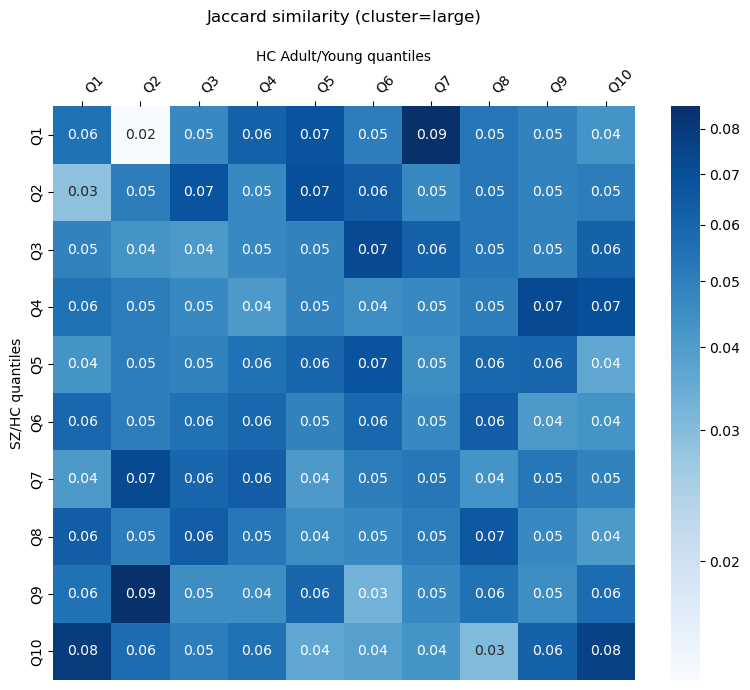

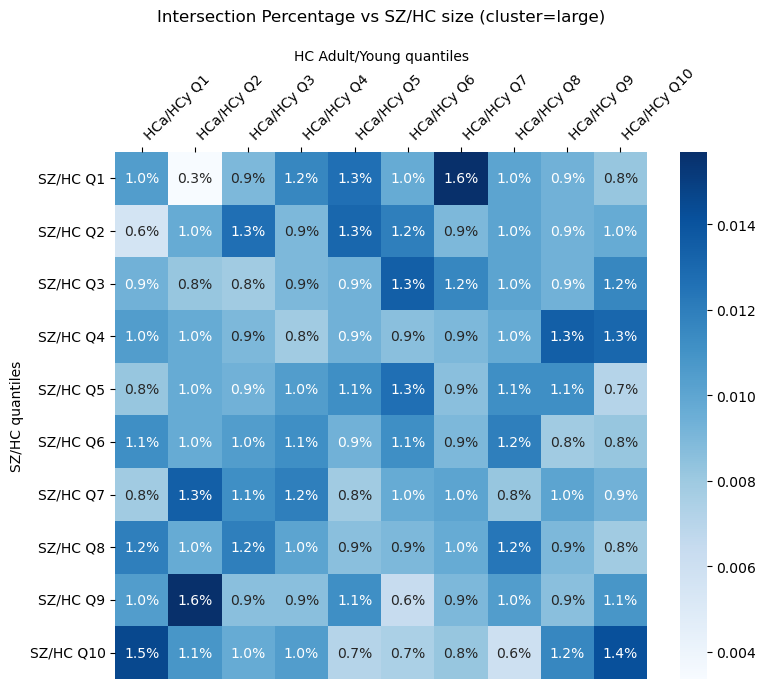

In [12]:
merged, similarity_matrix, intersection_percentage_matrix = loops_size_group_analysis(df,sizes_loops,  border_size_group_value='large')

[border_size_group=medium] Number of top_sz_hc: 277
[border_size_group=medium] Number of top_hc_age: 277
[border_size_group=medium] Number of overlapping clusters in top quantile: 37
[border_size_group=medium] Fisher's exact test p-value for enrichment: 0.0363, odds ratio: 1.44


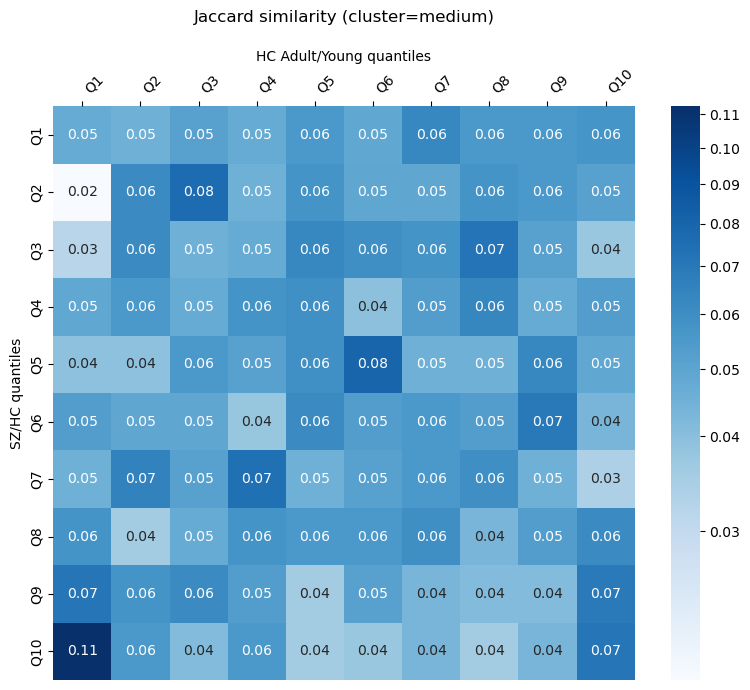

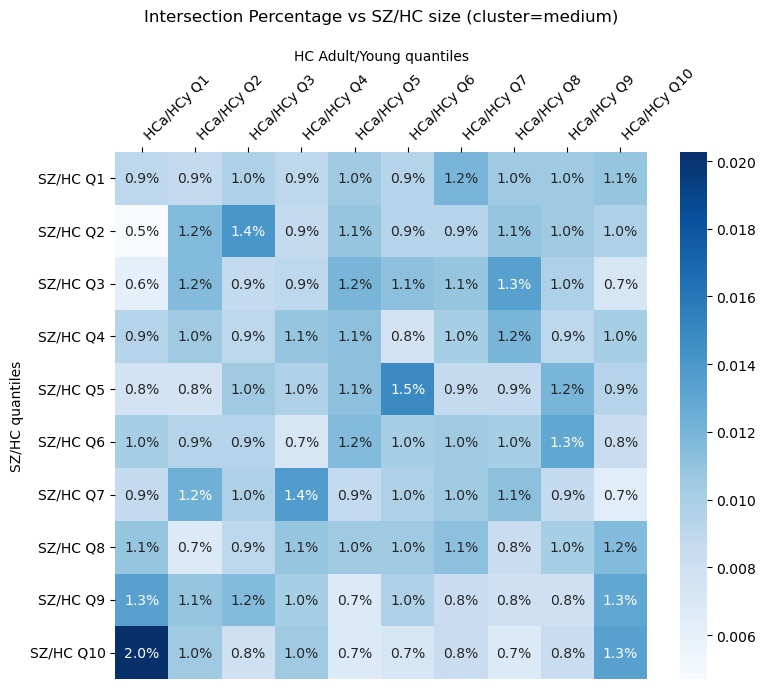

In [13]:
merged, similarity_matrix, intersection_percentage_matrix = loops_size_group_analysis(df,sizes_loops,  border_size_group_value='medium')

[border_size_group=small] Number of top_sz_hc: 271
[border_size_group=small] Number of top_hc_age: 271
[border_size_group=small] Number of overlapping clusters in top quantile: 26
[border_size_group=small] Fisher's exact test p-value for enrichment: 0.626, odds ratio: 0.95


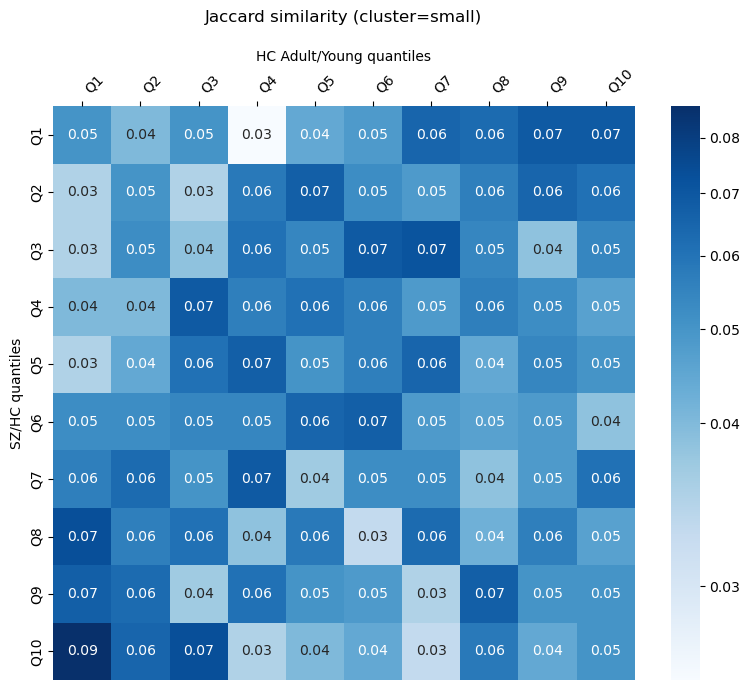

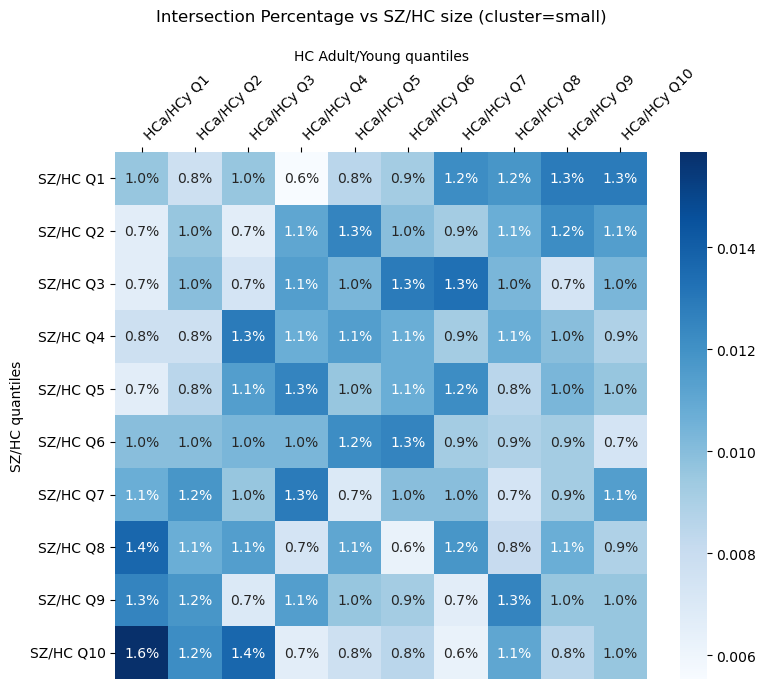

In [14]:
merged, similarity_matrix, intersection_percentage_matrix = loops_size_group_analysis(df,sizes_loops,  border_size_group_value='small')

[border_size_group=ALL] Number of top_sz_hc: 815
[border_size_group=ALL] Number of top_hc_age: 815
[border_size_group=ALL] Number of overlapping clusters in top quantile: 108
[border_size_group=ALL] Fisher's exact test p-value for enrichment: 0.000991, odds ratio: 1.43


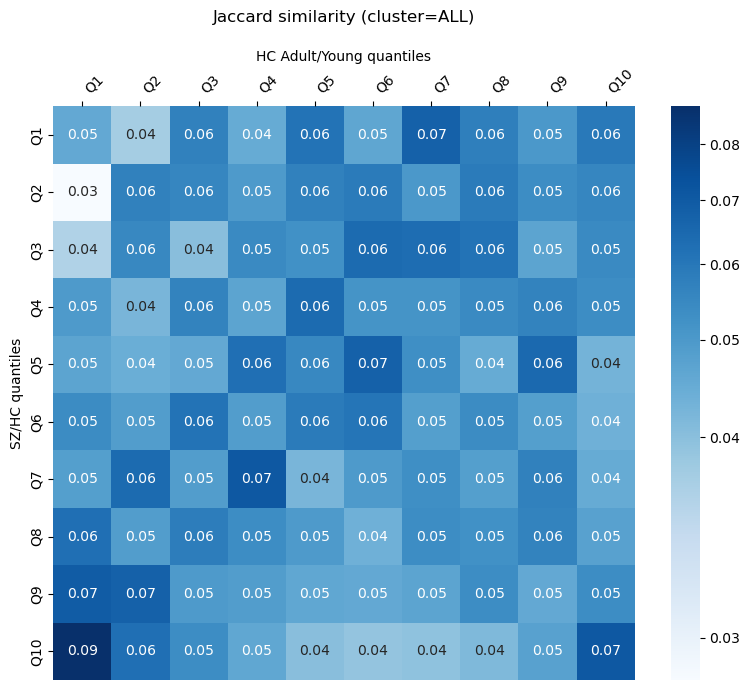

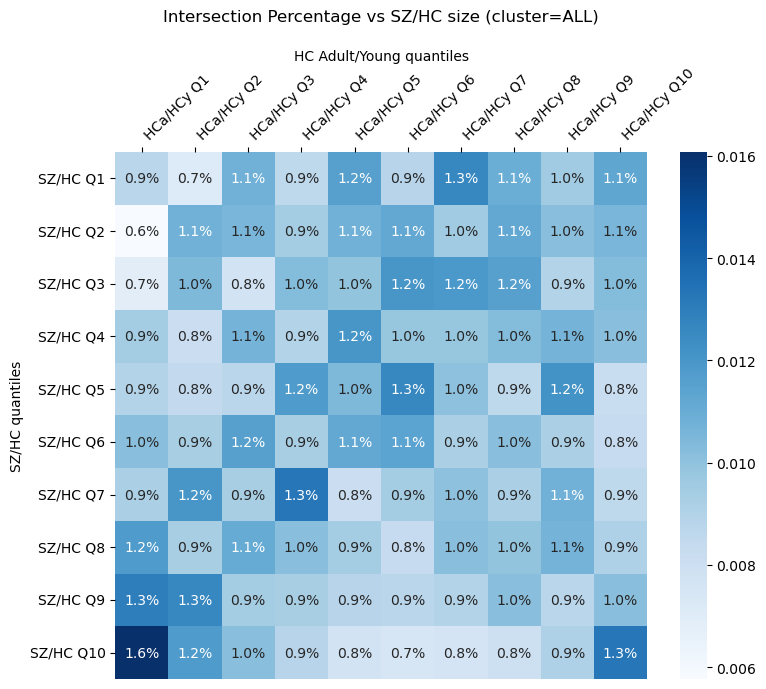

In [15]:
merged, similarity_matrix, intersection_percentage_matrix = loops_size_group_analysis(df,sizes_loops,  border_size_group_value='ALL', apply_filter=False)